In [1]:
# Hyperparameters
BATCH_SIZE = 128
TRAIN_SPLIT = 0.7
VALIDATION_SPLIT = 0.15
BLOCK_DROPOUT=0.4

# Trainer configuration
TRAINER_CFG={
    "num_epochs" : 35,
    "learning_rate" : 0.001,
    "patience" : 3,
    "use_scheduler" : True,
    "checkpoint_path" : "best_model.pth",
    "load_checkpoint" : False,
    "checkpoint_interval" : 5
}

### Dataset definition

In [2]:
import torch
import glob
import pickle
from enum import IntEnum

from attr import dataclass
from torch.nn.functional import dropout
from torch.utils.data import Dataset


class CollisionLabel(IntEnum):
    SAFE = 0
    WARNING = 1
    CRITICAL = 2


class CollisionDataset(Dataset):
    def __init__(self, root_dir, mode, window_size=None, transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.window_size = window_size
        self.transform = transform

        self.data = []
        self.labels = []
        self.subject_indices = {}

        current_idx = 0
        samples_dir = os.path.join(root_dir, 'samples')
        subjects = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

        for subj in subjects:
            self.subject_indices[subj] = []
            subj_sample_path = os.path.join(samples_dir, subj)
            label_type = 'static' if mode == 'static' else 'dynamic'
            subj_label_path = os.path.join(root_dir, 'labels', label_type, subj)
            pkl_files = sorted(glob.glob(os.path.join(subj_sample_path, '*.pkl')))

            for pkl_f in pkl_files:
                file_name_no_ext = os.path.splitext(os.path.basename(pkl_f))[0]
                label_name = f"{file_name_no_ext}_labels.npy"
                npy_f = os.path.join(subj_label_path, label_name)

                if not os.path.exists(npy_f):
                    raise FileNotFoundError(f"Could not load label: {npy_f}")

                with open(pkl_f, 'rb') as f:
                    raw_data = pickle.load(f)

                human_seq = np.array([frame[0] for frame in raw_data])
                robot_seq = np.array([frame[1] for frame in raw_data])
                human_flat = human_seq.reshape(human_seq.shape[0], -1)
                robot_flat = robot_seq.reshape(robot_seq.shape[0], -1)
                features = np.concatenate((human_flat, robot_flat), axis=1)

                targets = np.load(npy_f)
                num_frames = features.shape[0]

                if self.mode == 'static':
                    for i in range(num_frames):
                        self.data.append(features[i])
                        self.labels.append(targets[i])
                        self.subject_indices[subj].append(current_idx)
                        current_idx += 1

                elif self.mode == 'dynamic':
                    if window_size is None:
                        raise ValueError("Parameter window_size is required for dynamic mode")

                    for i in range(num_frames):
                        start_idx = i - window_size + 1

                        if start_idx < 0:
                            real_data = features[0: i + 1]
                            missing_count = window_size - real_data.shape[0]
                            padding = np.tile(features[0], (missing_count, 1))
                            window_x = np.concatenate((padding, real_data), axis=0)
                        else:
                            window_x = features[start_idx: i + 1]

                        self.data.append(window_x)
                        self.labels.append(targets[i])
                        self.subject_indices[subj].append(current_idx)
                        current_idx += 1

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform is not None:
            x = self.transform(x)

        return x, y

    def get_indices_for_subjects(self, subject_list):
        indices = []
        for subj in subject_list:
            if subj in self.subject_indices:
                indices.extend(self.subject_indices[subj])
        return indices

    def get_stats(self):
        return np.mean(self.data, axis=0), np.std(self.data, axis=0)

### Data augmentation tools

In [3]:
class TransformedSubset(Dataset):
    """Wrapper for dynamically applying transforms to Subset objects"""

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


class GaussianNoise(object):
    """Adds gaussian noise to samples for data augmentation."""

    def __init__(self, mean=0., std=0.01):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"


class Normalize(object):
    """Performs Z-Score normalization."""

    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        #Avoids zero division
        self.std = torch.clamp(torch.tensor(std, dtype=torch.float32), min=1e-7)

    def __call__(self, tensor):
        return (tensor - self.mean) / self.std

### Trainer definition

In [4]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import copy
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

class Trainer:
    def __init__(self,
                 model: nn.Module,
                 loaders: dict,
                 device,
                 loss_criterion=nn.CrossEntropyLoss(),
                 optimizer_cls=optim.Adam,
                 optimizer_kwargs=None
                 ):

        self.device = device
        print(f"Trainer initialized on device: {self.device}")
        self.model = model.to(self.device)
        self.loaders = loaders
        self.criterion = loss_criterion.to(self.device)
        self.optimizer_cls = optimizer_cls
        self.optimizer_kwargs = optimizer_kwargs if optimizer_kwargs else {}

    def train(self):
        optimizer = self.optimizer_cls(self.model.parameters(), lr=TRAINER_CFG["learning_rate"], **self.optimizer_kwargs)

        scheduler = None
        if TRAINER_CFG["use_scheduler"]:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

        if TRAINER_CFG["load_checkpoint"]:
            if os.path.isfile(TRAINER_CFG["checkpoint_path"]):
                self.model.load_state_dict(torch.load(TRAINER_CFG["checkpoint_path"], self.device))
                print('Loaded model checkpoint.')

        history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': [],
            'val_precision': [], 'val_recall': [], 'val_f1': []
        }

        best_val_f1 = 0.0  # Ottimizziamo per F1-macro invece della semplice loss
        patience_counter = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())

        for epoch in range(TRAINER_CFG["num_epochs"]):
            self.model.train()
            t_loss, t_corr, t_total = 0.0, 0, 0

            for inputs, labels in self.loaders['train']:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                t_loss += loss.item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                t_total += labels.size(0)
                t_corr += (pred == labels).sum().item()

            epoch_t_loss = t_loss / t_total
            epoch_t_acc = t_corr / t_total

            # --- VALIDATION ---
            self.model.eval()
            v_loss, v_corr, v_total = 0.0, 0, 0
            best_val_loss=10000 # big value
            val_preds, val_labels = [], []

            with torch.no_grad():
                for inputs, labels in self.loaders['validation']:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                    v_loss += loss.item() * inputs.size(0)
                    _, pred = torch.max(outputs, 1)
                    v_total += labels.size(0)
                    v_corr += (pred == labels).sum().item()

                    val_preds.extend(pred.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            epoch_v_loss = v_loss / v_total
            epoch_v_acc = v_corr / v_total

            # Calcolo metriche dettagliate per epoca (Macro)
            precision, recall, f1, _ = precision_recall_fscore_support(
                val_labels, val_preds, average='macro', zero_division=0
            )

            history['train_loss'].append(epoch_t_loss)
            history['train_acc'].append(epoch_t_acc)
            history['val_loss'].append(epoch_v_loss)
            history['val_acc'].append(epoch_v_acc)
            history['val_precision'].append(precision)
            history['val_recall'].append(recall)
            history['val_f1'].append(f1)

            print(f"Epoch {epoch + 1}/{TRAINER_CFG['num_epochs']}")
            print(f"  [Train] Loss: {epoch_t_loss:.4f} Acc: {epoch_t_acc*100:.2f}%")
            print(f"  [Val]   Loss: {epoch_v_loss:.4f} Acc: {epoch_v_acc*100:.2f}% | Prec: {precision:.3f} Rec: {recall:.3f} F1: {f1:.3f}")
            print(
                f"Epoch {epoch + 1}/{TRAINER_CFG['num_epochs']} | Train Loss: {epoch_t_loss:.4f} Acc: {epoch_t_acc * 100:.2f}% | Val Loss: {epoch_v_loss:.4f} Acc: {epoch_v_acc * 100:.2f}%")

            if TRAINER_CFG["use_scheduler"]:
                scheduler.step(epoch_v_loss)

            if epoch % TRAINER_CFG["checkpoint_interval"] == TRAINER_CFG["checkpoint_interval"] - 1:
                if epoch_v_loss < best_val_loss:
                    best_val_loss = epoch_v_loss
            # Early Stopping basato su F1-Macro (più affidabile per classi sbilanciate)
            if epoch % TRAINER_CFG["checkpoint_interval"] == TRAINER_CFG["checkpoint_interval"] - 1:
                if f1 > best_val_f1:
                    best_val_f1 = f1
                    patience_counter = 0
                    torch.save(self.model.state_dict(), TRAINER_CFG["checkpoint_path"])
                    best_model_wts = copy.deepcopy(self.model.state_dict())
                    print("    -> Model saved.")
                else:
                    patience_counter += 1
                    if patience_counter >= TRAINER_CFG["patience"]:
                        print("Early Stopping triggered.")
                        break

        self.model.load_state_dict(best_model_wts)
        self.evaluate_test()

        print("--- HISTORY ---")

        print('Train loss:')
        for epoch, val in enumerate(history['train_loss']):
            print(f"\tEpoch {epoch} | {val:.3f}")

        print('Train accuracy:')
        for epoch, val in enumerate(history['train_acc']):
            print(f"\tEpoch {epoch} | {val * 100:.3}%")

        print('Validation loss:')
        for epoch, val in enumerate(history['val_loss']):
            print(f"\tEpoch {epoch} | {val:.3f}")

        print('Validation accuracy:')
        for epoch, val in enumerate(history['val_acc']):
            print(f"\tEpoch {epoch} | {val * 100:.3}%")

    def evaluate_test(self):
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in self.loaders['test']:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)

                # Calcola le probabilità (Softmax)
                probs = torch.softmax(outputs, dim=1)

                preds = []
                for p in probs:
                    preds.append(torch.argmax(p).item())

                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        print("--- TEST REPORT ---")
        target_names = ['SAFE', 'WARNING', 'CRITICAL']
        print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

        self._plot_confusion_matrix(all_labels, all_preds, classes=target_names, normalize=False)

    @staticmethod
    def _plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title='Confusion Matrix'):
        cm = confusion_matrix(y_true, y_pred)

        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            fmt = '.2f'
        else:
            fmt = 'd'

        plt.figure(figsize=(8, 6))
        sns.set_theme(font_scale=1.2)
        sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=classes, yticklabels=classes,
                    linewidths=.5, linecolor='black')

        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.title(title, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

### Phase 1: Frame-by-frame safety classifier

In [5]:
class StaticSafetyClassifier(nn.Module):
    def __init__(self, input_dimension, num_classes, train_mean, train_std):
        super().__init__()

        self.train_mean = train_mean
        self.train_std = train_std

        self.backbone = nn.Sequential(
            self._block(input_dimension, 128),
            self._block(128, 64),
            self._block(64, 32)
        )
        self._head = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self._head(x)
        return x

    def infer(self, x):
        self.eval()
        device = next(self.parameters()).device

        with torch.no_grad():
            x = (torch.tensor(x, dtype=torch.float32) - torch.tensor(self.train_mean, dtype=torch.float32)) / (
                        torch.tensor(self.train_std, dtype=torch.float32) + 1e-7)
            x = x.unsqueeze(0).to(device)

            output = self(x)
            prediction = torch.argmax(output, dim=1).item()
        return prediction

    @staticmethod
    def _block(in_f, out_f):
        return nn.Sequential(
            nn.Linear(in_f, out_f),
            nn.BatchNorm1d(out_f),
            nn.ReLU(),
            nn.Dropout(BLOCK_DROPOUT)
        )

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler, Subset
import torch.nn as nn
from torchvision import transforms

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

"""_____ STATIC DATASET _____"""

static_dataset = CollisionDataset(
    root_dir='../dataset/',
    mode='static'
)

input_dim = static_dataset[0][0].shape[0]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(static_dataset.labels),
    y=static_dataset.labels
)
static_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Computed weights: {static_weights_tensor}")

static_criterion = nn.CrossEntropyLoss()
all_subjects = sorted(list(static_dataset.subject_indices.keys()))

# 1. Calcola il conteggio dei frame per ogni classe (SAFE=0, WARNING=1, CRITICAL=2) per ciascun soggetto
subject_counts = {}
for subj in all_subjects:
    subj_labels = static_dataset.labels[static_dataset.subject_indices[subj]]
    subject_counts[subj] = np.bincount(subj_labels, minlength=3)

# 2. Ordina i soggetti in modo decrescente in base al numero di frame CRITICAL
sorted_subjs = sorted(all_subjects, key=lambda s: subject_counts[s][2], reverse=True)

train_subjs, val_subjs, test_subjs = [], [], []
counts_train, counts_val, counts_test = np.zeros(3), np.zeros(3), np.zeros(3)

# 3. Distribuisci i soggetti minimizzando la discrepanza rispetto alle percentuali target (70%, 15%, 15%)
for subj in sorted_subjs:
    c = subject_counts[subj]
    tot_critical = counts_train[2] + counts_val[2] + counts_test[2] + c[2]

    if tot_critical == 0:
        tot_critical = 1 # Evita divisioni per zero se non ci sono frame critical

    diff_train = (counts_train[2] + c[2]) / tot_critical - TRAIN_SPLIT
    diff_val   = (counts_val[2] + c[2]) / tot_critical - VALIDATION_SPLIT
    diff_test  = (counts_test[2] + c[2]) / tot_critical - 0.15

    choice = np.argmin([diff_train, diff_val, diff_test])

    if choice == 0:
        train_subjs.append(subj)
        counts_train += c
    elif choice == 1:
        val_subjs.append(subj)
        counts_val += c
    else:
        test_subjs.append(subj)
        counts_test += c

print(f"Split:\n\tTrain: {train_subjs}\n\tValidation: {val_subjs}\n\tTest: {test_subjs}")

train_idx = static_dataset.get_indices_for_subjects(train_subjs)
val_idx = static_dataset.get_indices_for_subjects(val_subjs)
test_idx = static_dataset.get_indices_for_subjects(test_subjs)

train_data_raw = static_dataset.data[train_idx]
static_mean = np.mean(train_data_raw, axis=0)
static_std = np.std(train_data_raw, axis=0)

train_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std),
    GaussianNoise(0, 0.05)
])

eval_transforms = transforms.Compose([
    Normalize(mean=static_mean, std=static_std)
])

train_subset = TransformedSubset(
    Subset(static_dataset, train_idx),
    train_transforms
)
val_subset = TransformedSubset(
    Subset(static_dataset, val_idx),
    eval_transforms
)
test_subset = TransformedSubset(
    Subset(static_dataset, test_idx),
    eval_transforms
)

train_labels = static_dataset.labels[train_idx]
# Calcola i pesi per ogni campione nel set di training
class_sample_count = np.bincount(train_labels)
# La radice quadrata attenua la forza del bilanciamento
class_weights = 1. / np.sqrt(class_sample_count)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

loaders = {
    # Rimuovi shuffle=True, non è compatibile con il sampler
    'train': DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler),
    'validation': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False),
    'test': DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)
}
static_classifier = StaticSafetyClassifier(input_dim, len(CollisionLabel), static_mean, static_std)

static_trainer = Trainer(
    static_classifier,
    loaders,
    device=device,
    loss_criterion=static_criterion
)

Computed weights: tensor([ 0.3718,  3.3607, 78.7697], device='cuda:0')
Split:
	Train: ['S10', 'S17', 'S11', 'S01', 'S19', 'S05', 'S07', 'S13', 'S02', 'S15', 'S00', 'S14', 'S18', 'S09']
	Validation: ['S12', 'S03', 'S04']
	Test: ['S08', 'S16', 'S06']
Trainer initialized on device: cuda


Epoch 1/35
  [Train] Loss: 0.2975 Acc: 87.43%
  [Val]   Loss: 0.1356 Acc: 93.60% | Prec: 0.672 Rec: 0.841 F1: 0.735
Epoch 1/35 | Train Loss: 0.2975 Acc: 87.43% | Val Loss: 0.1356 Acc: 93.60%
Epoch 2/35
  [Train] Loss: 0.2061 Acc: 91.35%
  [Val]   Loss: 0.1109 Acc: 94.64% | Prec: 0.722 Rec: 0.885 F1: 0.785
Epoch 2/35 | Train Loss: 0.2061 Acc: 91.35% | Val Loss: 0.1109 Acc: 94.64%
Epoch 3/35
  [Train] Loss: 0.1810 Acc: 92.48%
  [Val]   Loss: 0.1011 Acc: 95.42% | Prec: 0.718 Rec: 0.839 F1: 0.768
Epoch 3/35 | Train Loss: 0.1810 Acc: 92.48% | Val Loss: 0.1011 Acc: 95.42%
Epoch 4/35
  [Train] Loss: 0.1726 Acc: 92.90%
  [Val]   Loss: 0.0859 Acc: 96.40% | Prec: 0.740 Rec: 0.822 F1: 0.775
Epoch 4/35 | Train Loss: 0.1726 Acc: 92.90% | Val Loss: 0.0859 Acc: 96.40%
Epoch 5/35
  [Train] Loss: 0.1637 Acc: 93.36%
  [Val]   Loss: 0.0965 Acc: 95.86% | Prec: 0.704 Rec: 0.850 F1: 0.758
Epoch 5/35 | Train Loss: 0.1637 Acc: 93.36% | Val Loss: 0.0965 Acc: 95.86%
    -> Model saved.
Epoch 6/35
  [Train] Loss

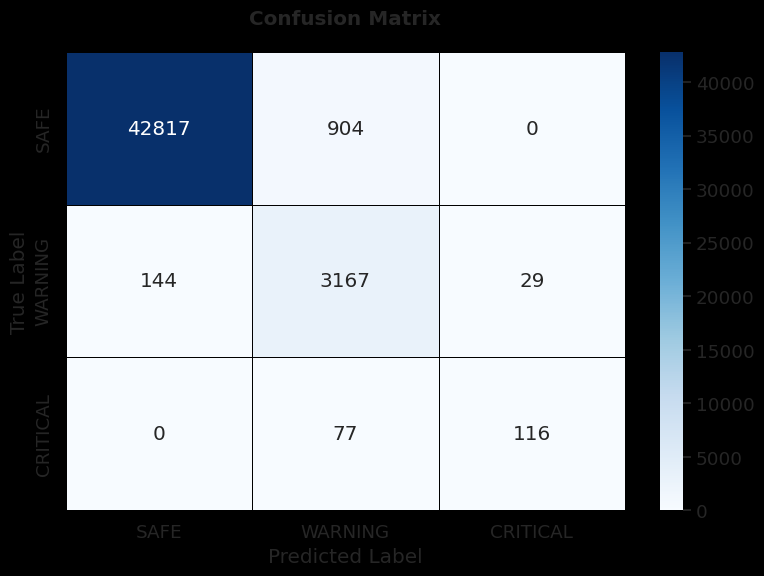

--- HISTORY ---
Train loss:
	Epoch 0 | 0.297
	Epoch 1 | 0.206
	Epoch 2 | 0.181
	Epoch 3 | 0.173
	Epoch 4 | 0.164
	Epoch 5 | 0.158
	Epoch 6 | 0.154
	Epoch 7 | 0.152
	Epoch 8 | 0.141
	Epoch 9 | 0.137
	Epoch 10 | 0.136
	Epoch 11 | 0.135
	Epoch 12 | 0.132
	Epoch 13 | 0.132
	Epoch 14 | 0.134
	Epoch 15 | 0.130
	Epoch 16 | 0.130
	Epoch 17 | 0.133
	Epoch 18 | 0.130
	Epoch 19 | 0.128
	Epoch 20 | 0.130
	Epoch 21 | 0.130
	Epoch 22 | 0.129
	Epoch 23 | 0.130
	Epoch 24 | 0.132
	Epoch 25 | 0.131
	Epoch 26 | 0.131
	Epoch 27 | 0.129
	Epoch 28 | 0.130
	Epoch 29 | 0.131
Train accuracy:
	Epoch 0 | 87.4%
	Epoch 1 | 91.3%
	Epoch 2 | 92.5%
	Epoch 3 | 92.9%
	Epoch 4 | 93.4%
	Epoch 5 | 93.6%
	Epoch 6 | 93.8%
	Epoch 7 | 93.9%
	Epoch 8 | 94.4%
	Epoch 9 | 94.6%
	Epoch 10 | 94.6%
	Epoch 11 | 94.8%
	Epoch 12 | 94.8%
	Epoch 13 | 94.8%
	Epoch 14 | 94.7%
	Epoch 15 | 94.9%
	Epoch 16 | 94.9%
	Epoch 17 | 94.8%
	Epoch 18 | 94.9%
	Epoch 19 | 95.1%
	Epoch 20 | 94.9%
	Epoch 21 | 94.9%
	Epoch 22 | 94.9%
	Epoch 23 | 94.9%
	Epo

In [7]:
static_trainer.train()